# Exploratory Data Analysis — Network Traffic Dataset

**Goal:** Understand the raw data, detect quality issues, visualise feature distributions and correlations, then produce a cleaned dataset for the feature-engineering step.  
**Output:** `../data/processed/cleaned_traffic_data.csv`

---

| Step | Action |
|------|--------|
| 1 | Imports & data loading |
| 2 | Missing & infinity value inspection |
| 3 | Duplicate detection |
| 4 | Class distribution analysis |
| 5 | Feature distributions (histogram + boxplot) |
| 6 | Class-wise feature comparison |
| 7 | Correlation matrix |
| 8 | High-correlation feature detection |
| 9 | Inf / NaN removal |
| 10 | Duplicate removal |
| 11 | Negative value correction |
| 12 | Export cleaned dataset |


## 1. Imports & Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = "../data/raw/consolidated_traffic_data.csv"

if os.path.exists(DATA_PATH):
    print("File found. Loading...")
    df = pd.read_csv(DATA_PATH)
else:
    raise FileNotFoundError(f"File not found at: {DATA_PATH}")

print(f"Shape: {df.shape}")
print(df.info())

File found. Loading...
Shape: (59706, 24)
<class 'pandas.DataFrame'>
RangeIndex: 59706 entries, 0 to 59705
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   duration            59706 non-null  float64
 1   total_fiat          59706 non-null  float64
 2   total_biat          59706 non-null  float64
 3   min_fiat            59706 non-null  float64
 4   min_biat            59706 non-null  float64
 5   max_fiat            59706 non-null  float64
 6   max_biat            59706 non-null  float64
 7   mean_fiat           59706 non-null  float64
 8   mean_biat           59706 non-null  float64
 9   flowPktsPerSecond   59706 non-null  float64
 10  flowBytesPerSecond  59706 non-null  float64
 11  min_flowiat         59706 non-null  float64
 12  max_flowiat         59706 non-null  float64
 13  mean_flowiat        59706 non-null  float64
 14  std_flowiat         59706 non-null  float64
 15  min_active          59

## 2. Missing & Infinity Values

In [2]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

inf_values = df.isin([np.inf, -np.inf]).sum()
print("\nInfinity values per column:")
print(inf_values[inf_values > 0])

Missing values per column:
Series([], dtype: int64)

Infinity values per column:
Series([], dtype: int64)


## 3. Duplicate Detection

In [3]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate row count: {duplicate_count}")

Duplicate row count: 18719


## 4. Class Distribution Analysis

No named target column found. Using last column: 'traffic_type'

Class distribution (count):
traffic_type
BROWSING         10000
VPN-BROWSING     10000
VOIP              6485
VPN-VOIP          5576
VPN-FT            4704
P2P               4000
FT                3975
VPN-P2P           3415
VPN-CHAT          2839
CHAT              2505
VPN-MAIL          2444
MAIL              1364
STREAMING         1284
VPN-STREAMING     1115
Name: count, dtype: int64

Class distribution (%):
traffic_type
BROWSING         16.748735
VPN-BROWSING     16.748735
VOIP             10.861555
VPN-VOIP          9.339095
VPN-FT            7.878605
P2P               6.699494
FT                6.657622
VPN-P2P           5.719693
VPN-CHAT          4.754966
CHAT              4.195558
VPN-MAIL          4.093391
MAIL              2.284528
STREAMING         2.150538
VPN-STREAMING     1.867484
Name: proportion, dtype: float64


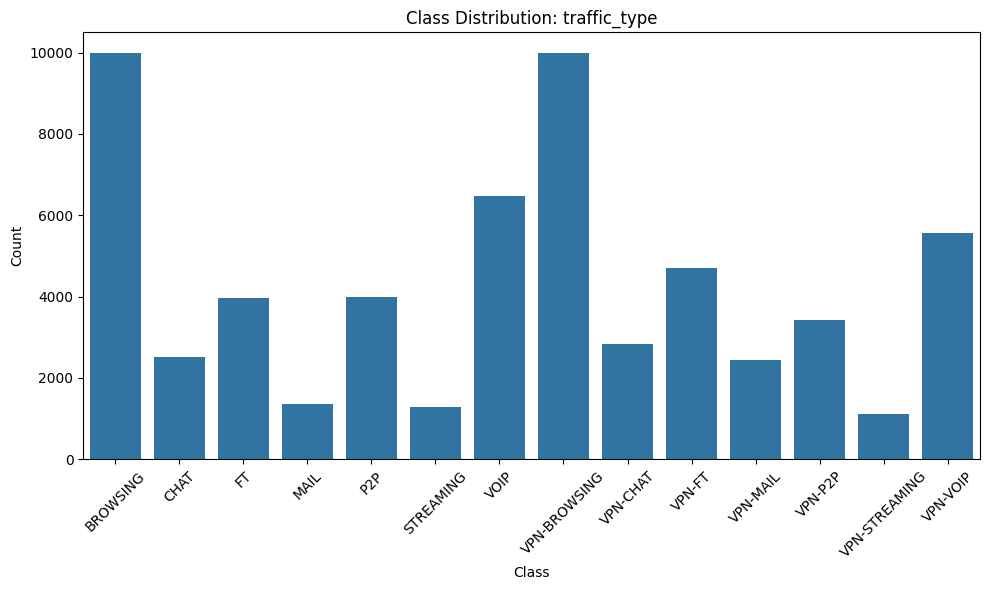

In [4]:
target_column = None
for col in df.columns:
    if col.lower() in ['target', 'label', 'class', 'sonuc', 'durum']:
        target_column = col
        break

if target_column is None:
    target_column = df.columns[-1]
    print(f"No named target column found. Using last column: '{target_column}'")
else:
    print(f"Target column detected: '{target_column}'")

print(f"\nClass distribution (count):\n{df[target_column].value_counts()}")
print(f"\nClass distribution (%):\n{df[target_column].value_counts(normalize=True) * 100}")

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=target_column)
plt.title(f"Class Distribution: {target_column}")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Feature Distributions — Histogram & Boxplot

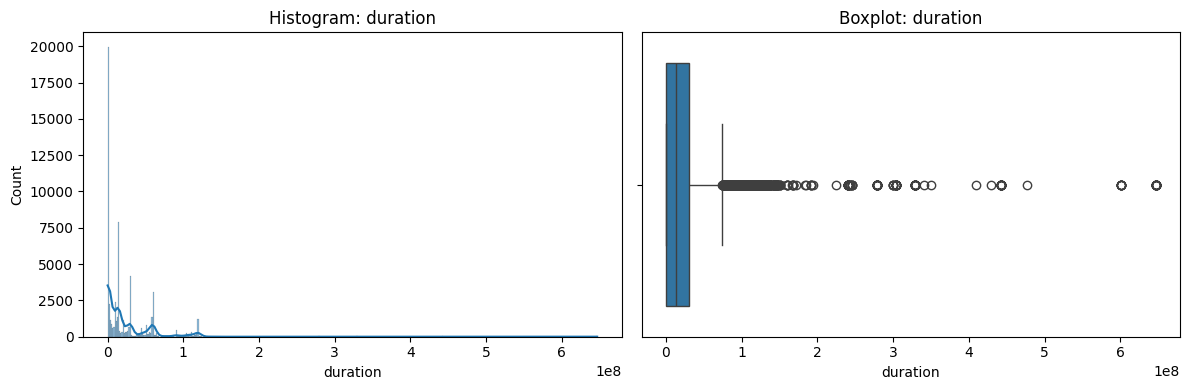

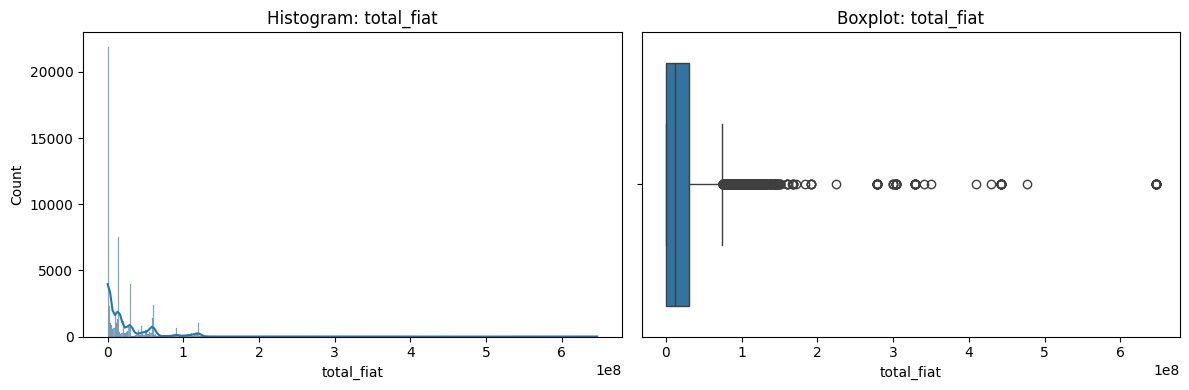

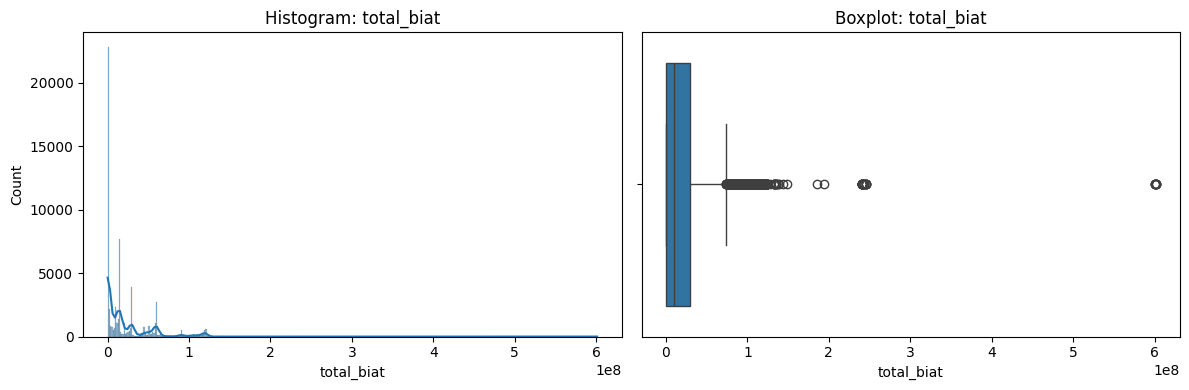

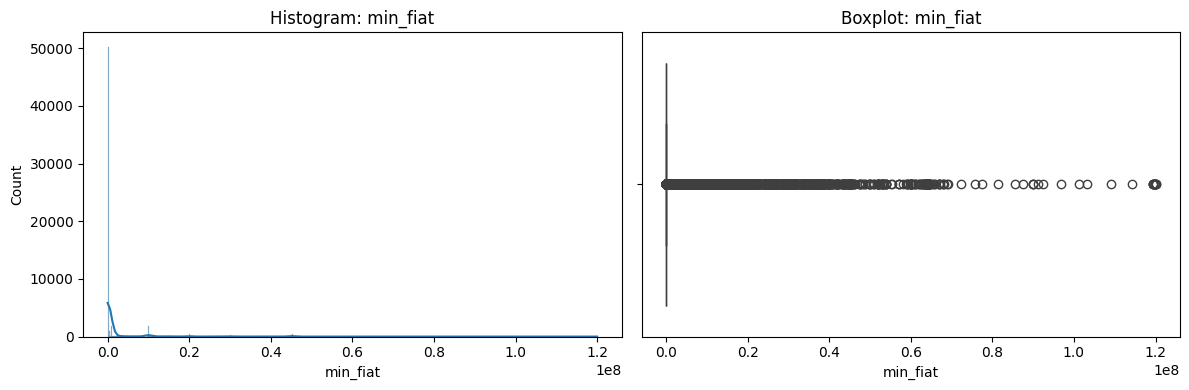

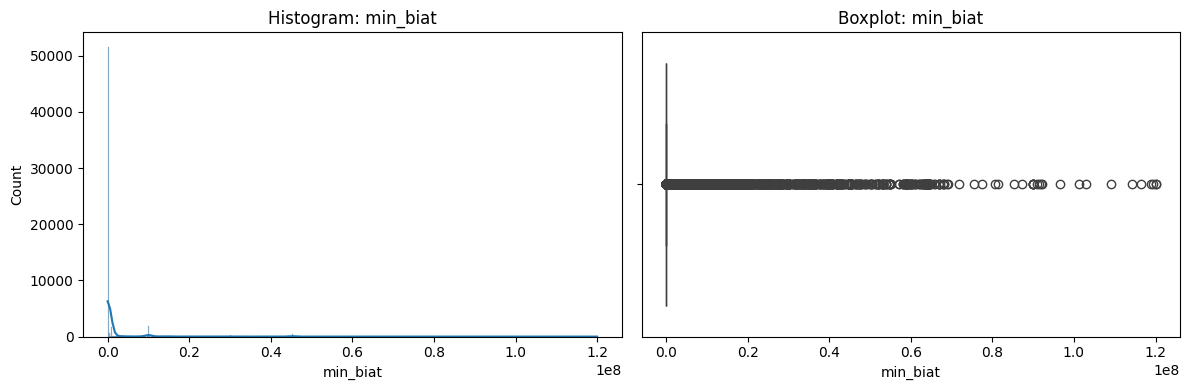

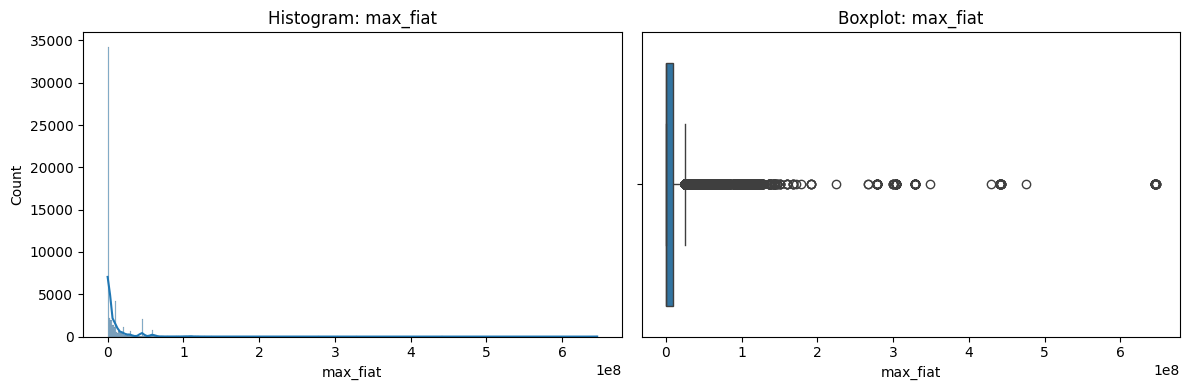

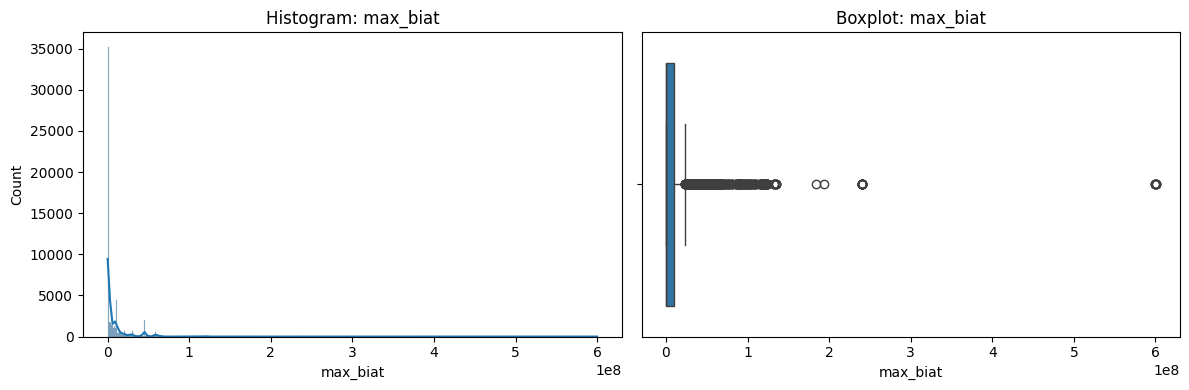

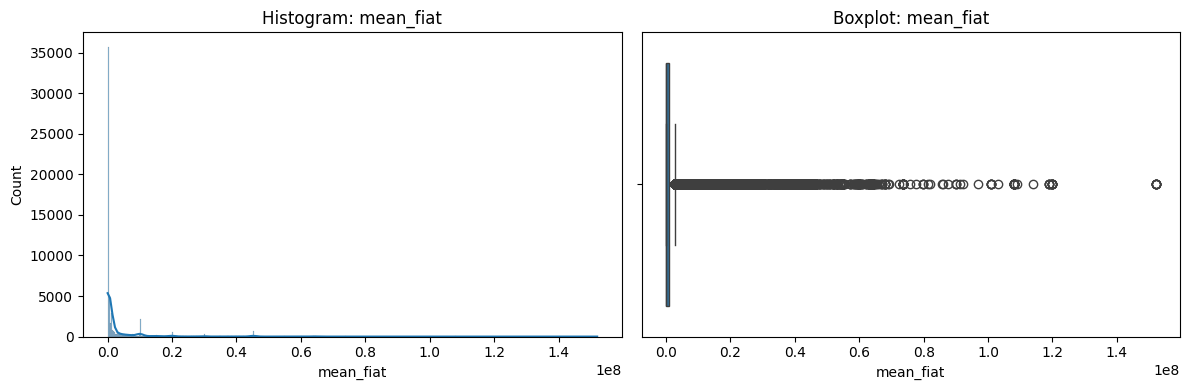

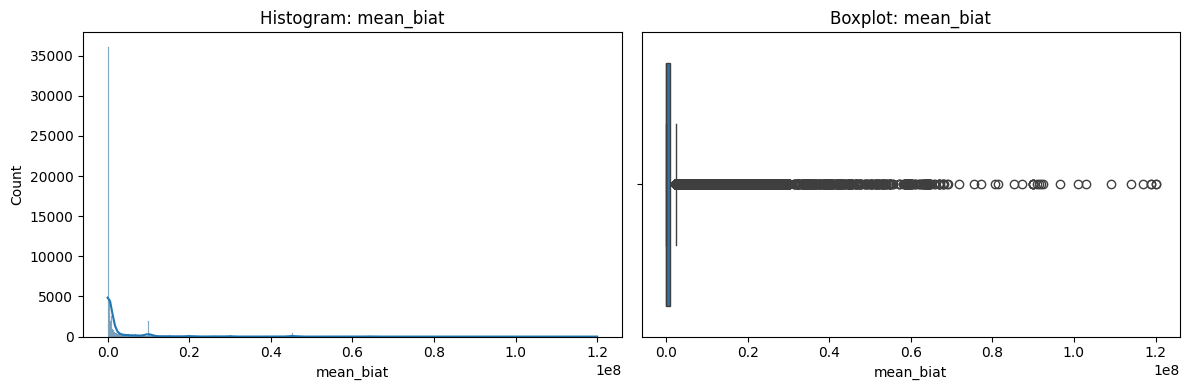

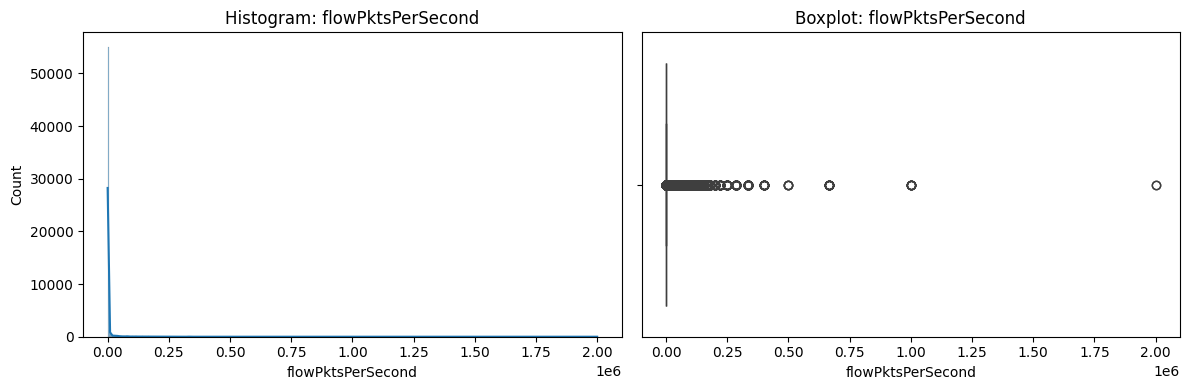

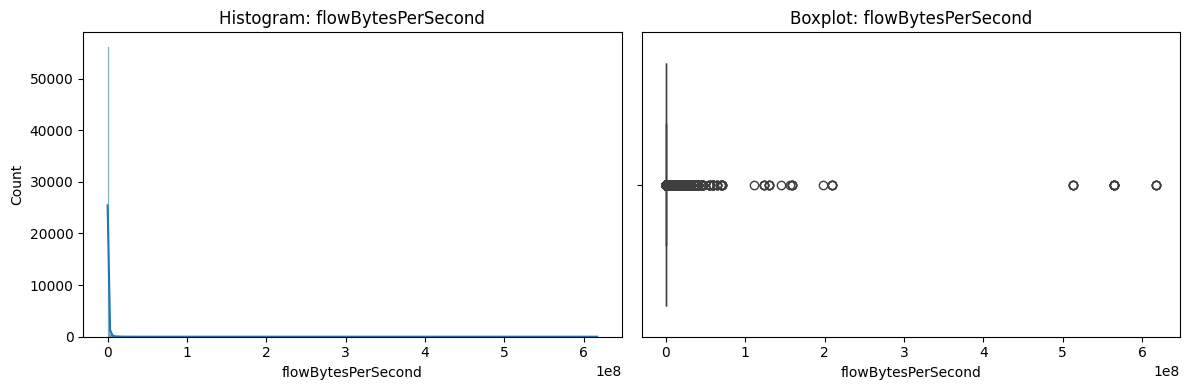

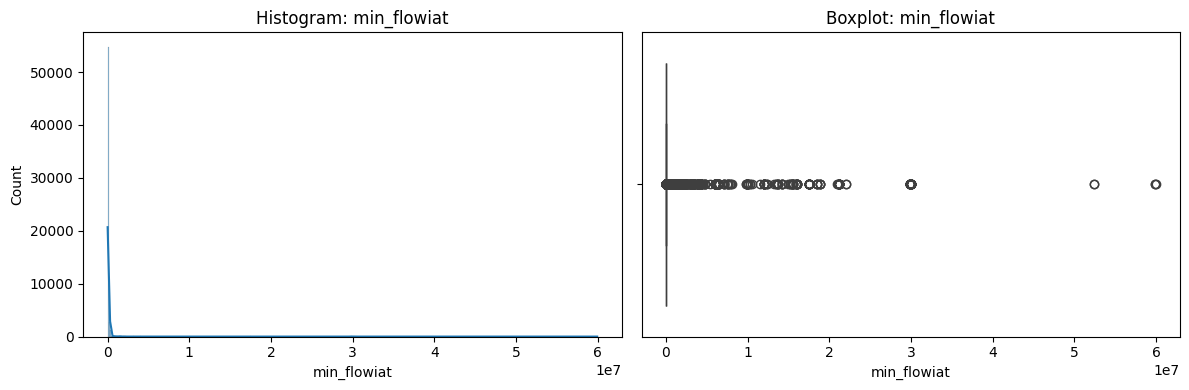

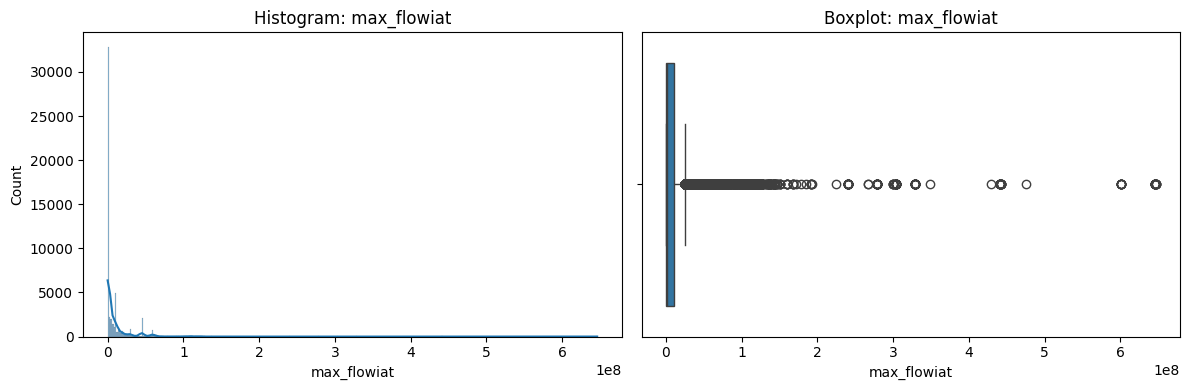

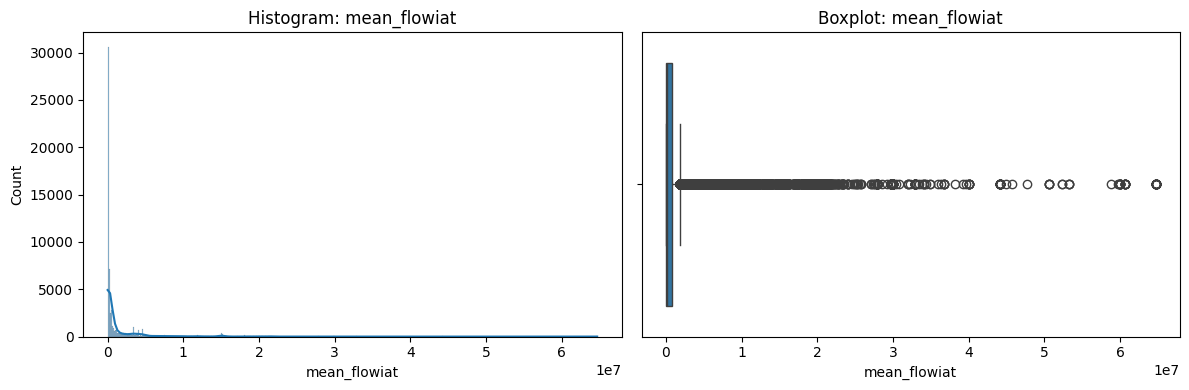

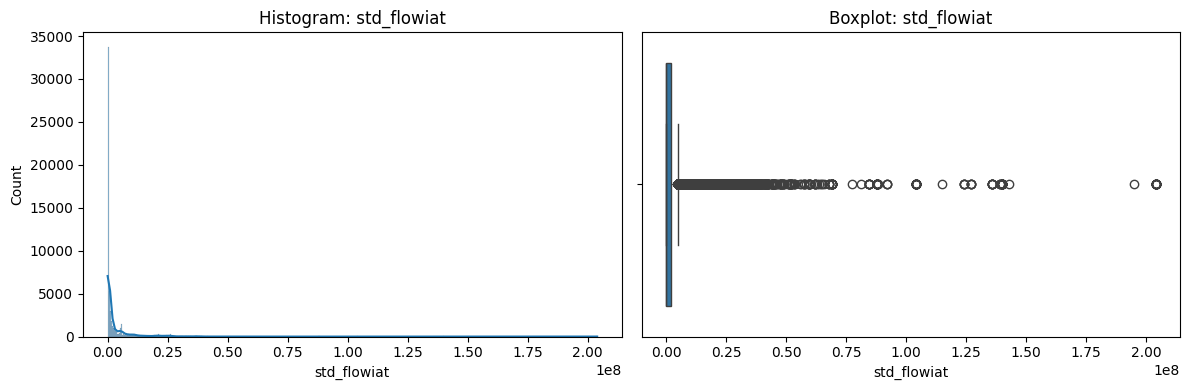

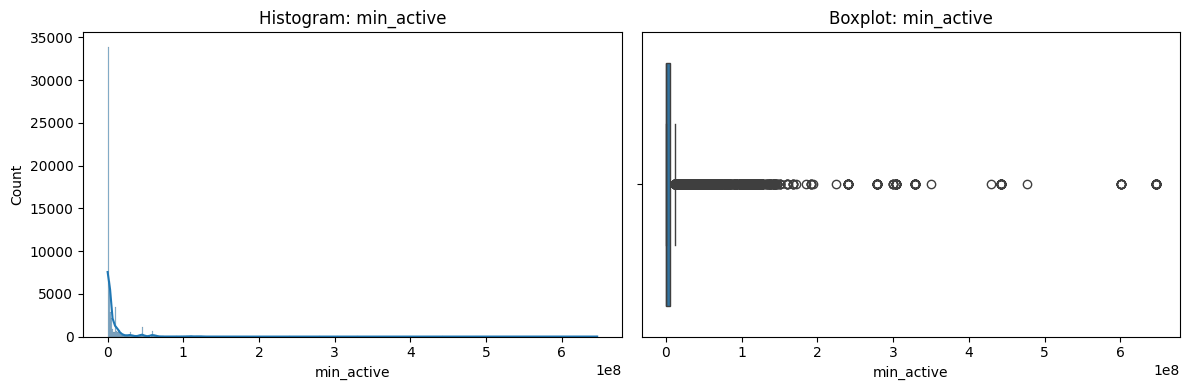

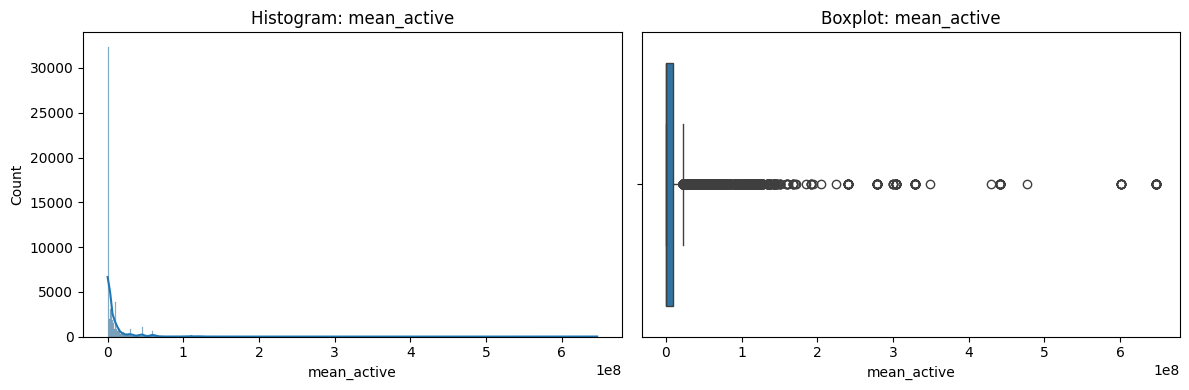

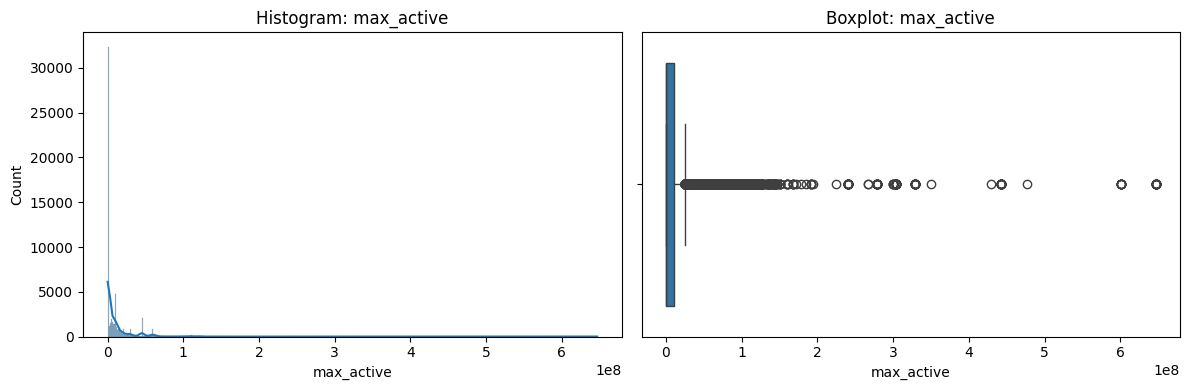

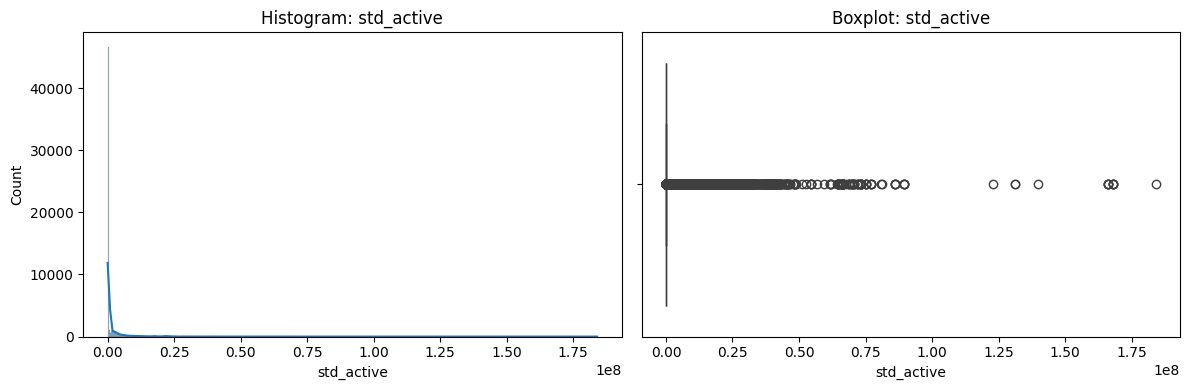

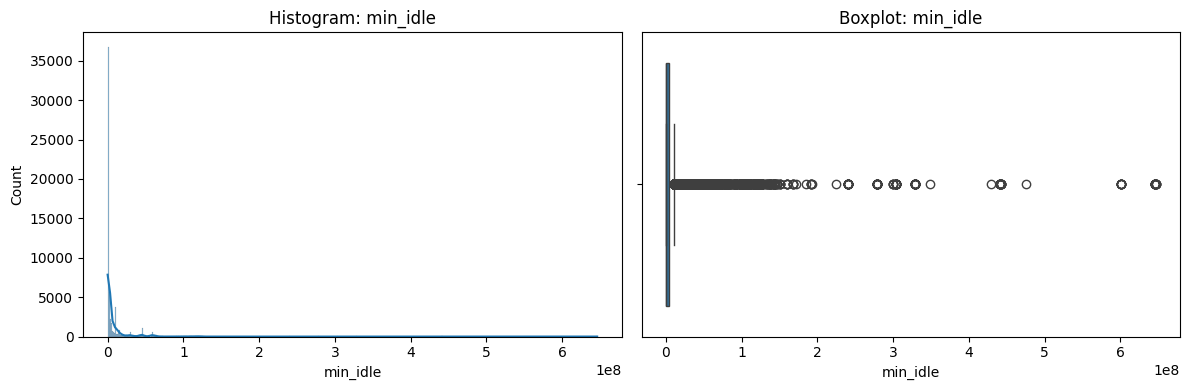

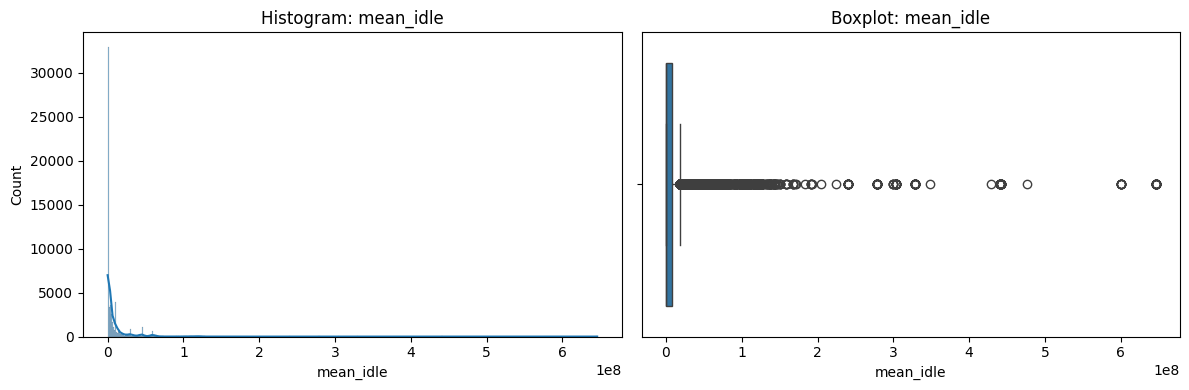

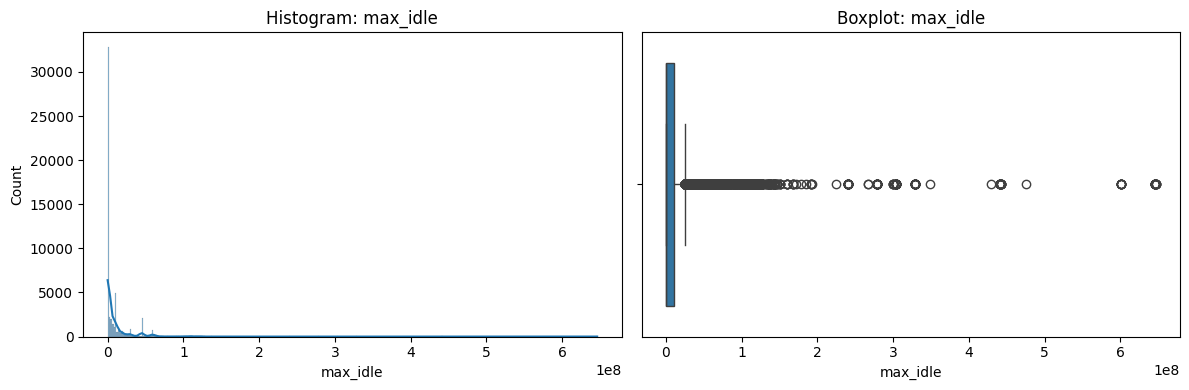

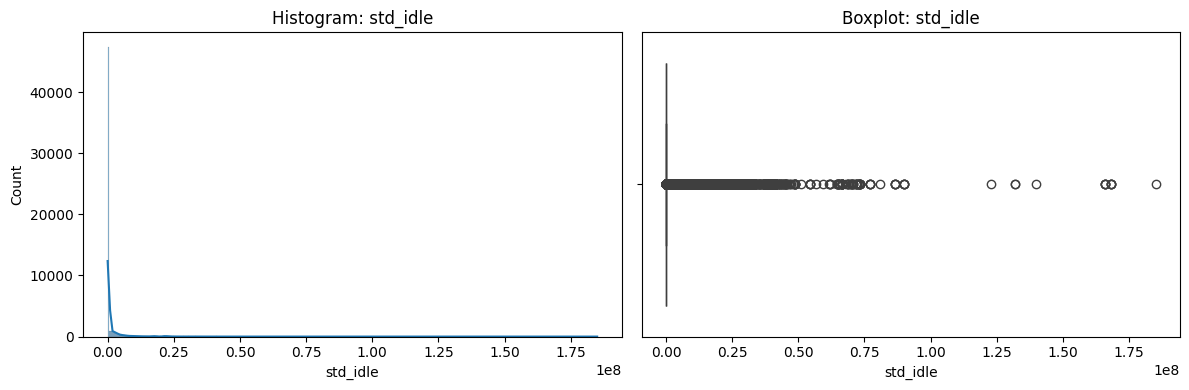

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram: {col}")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

## 6. Class-wise Feature Comparison

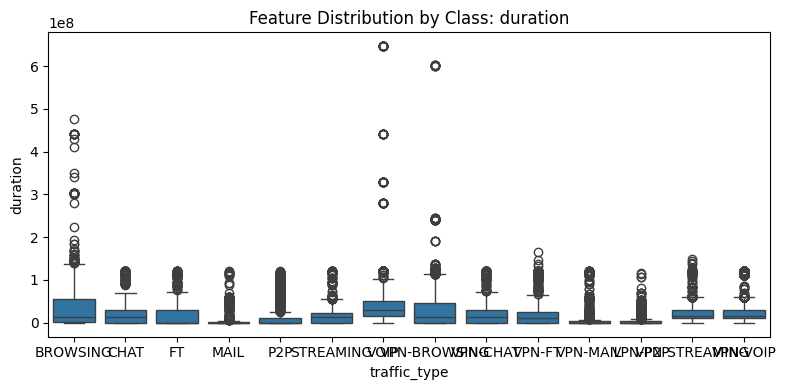

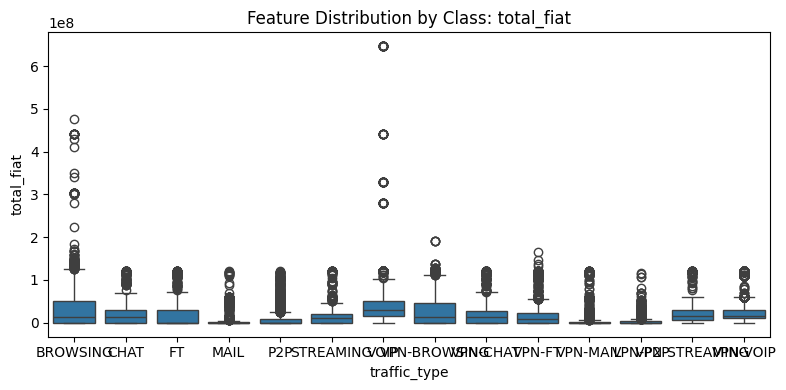

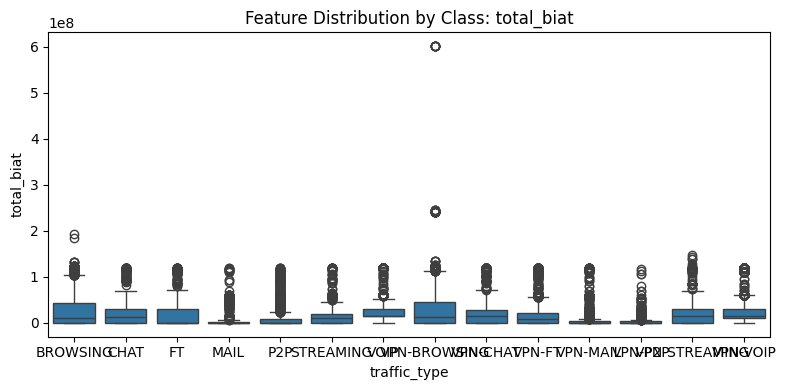

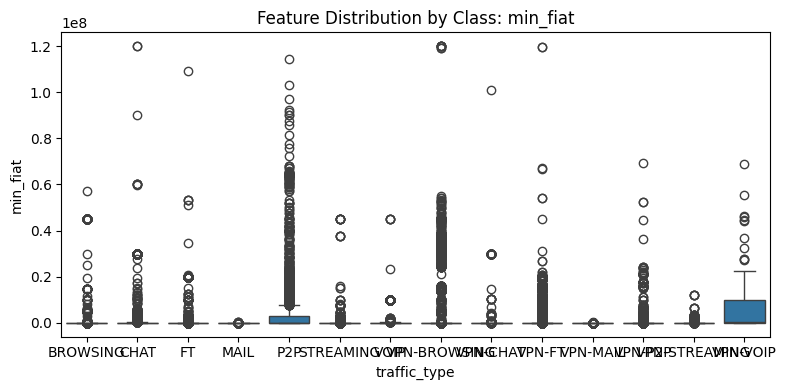

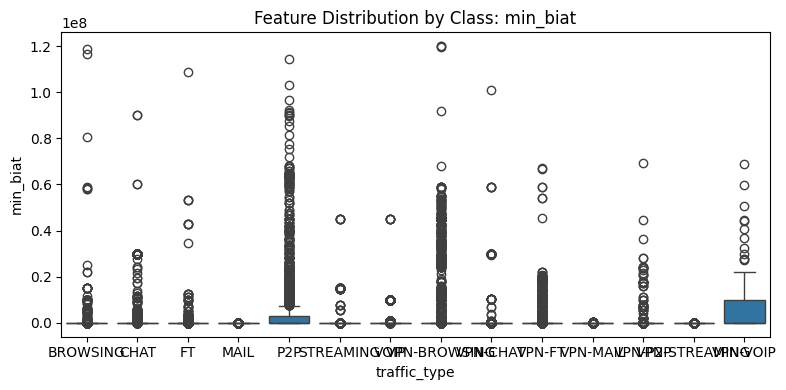

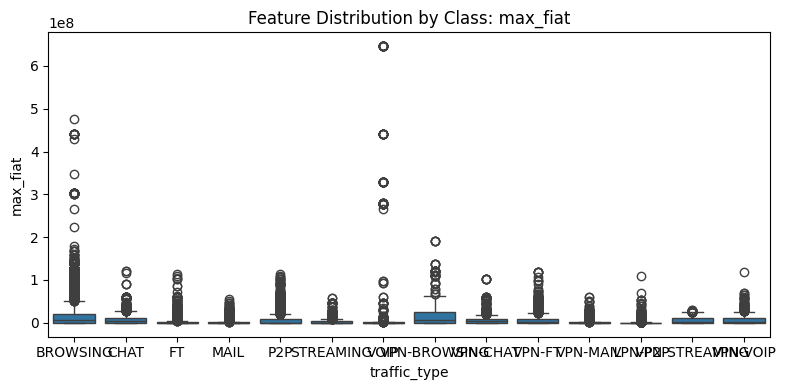

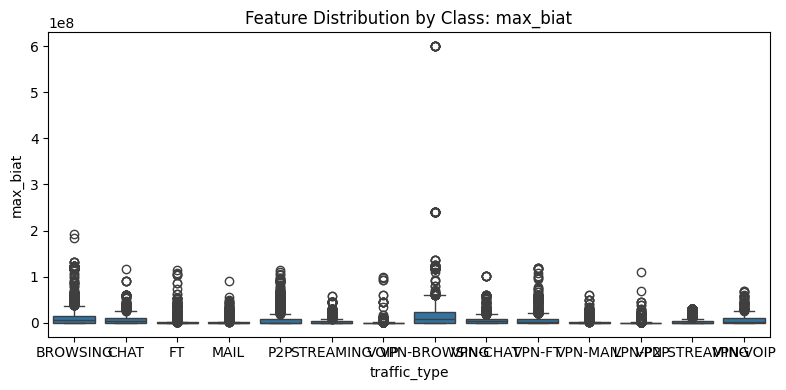

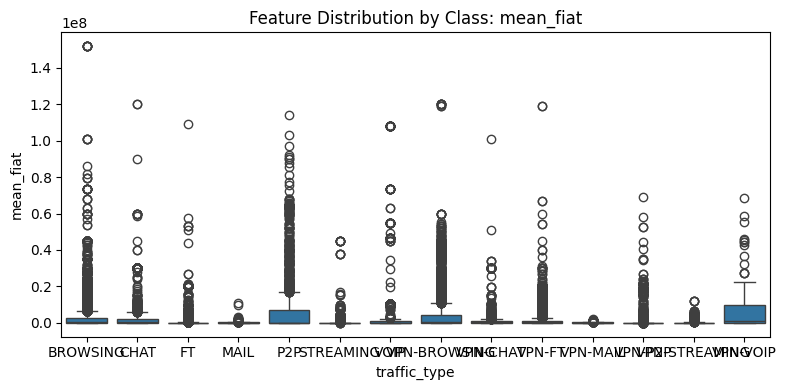

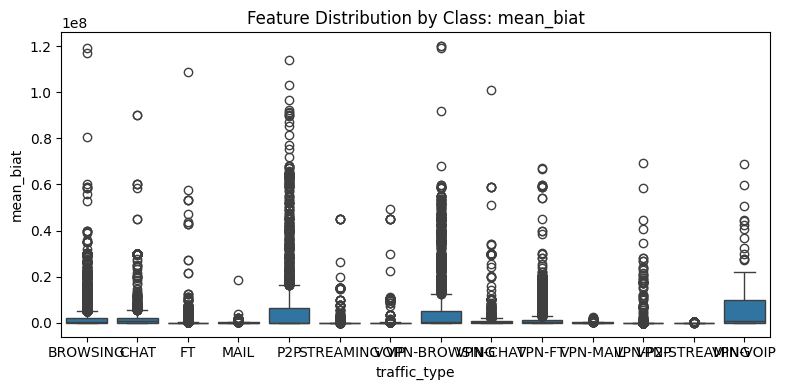

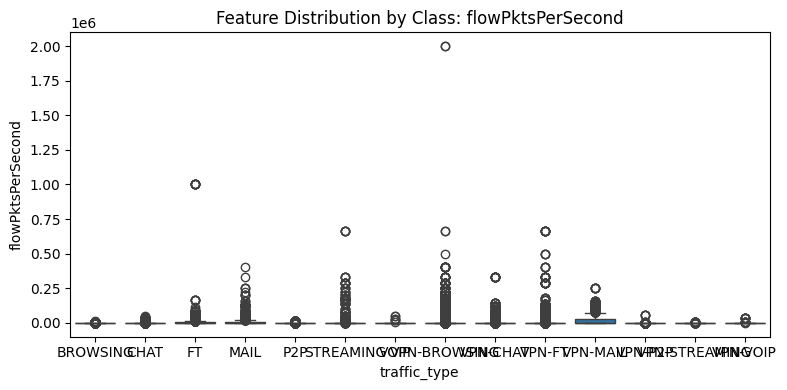

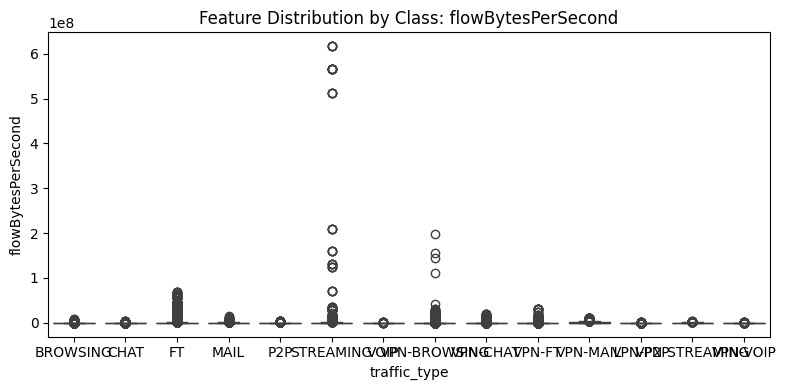

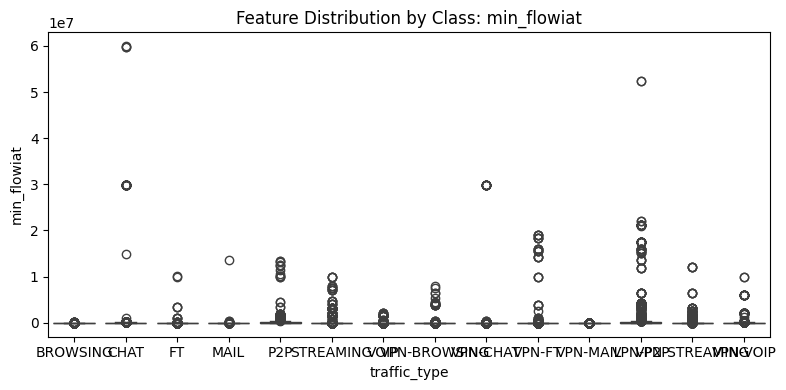

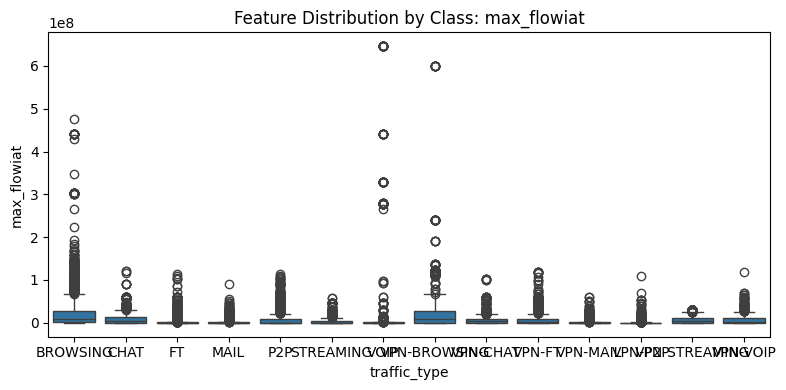

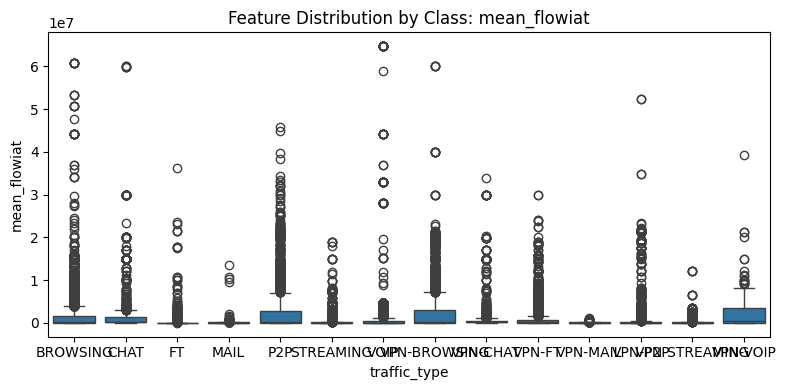

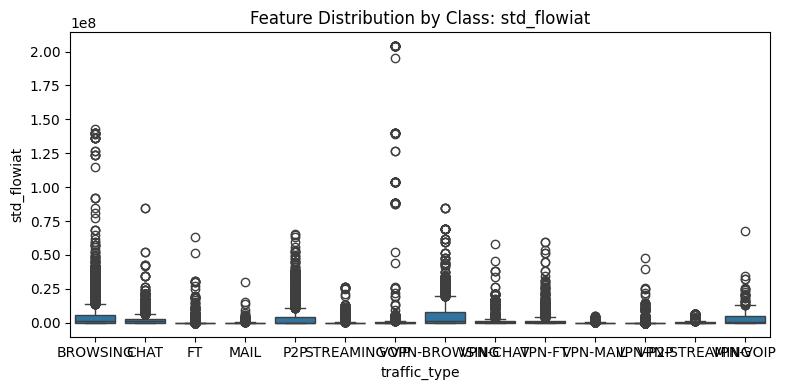

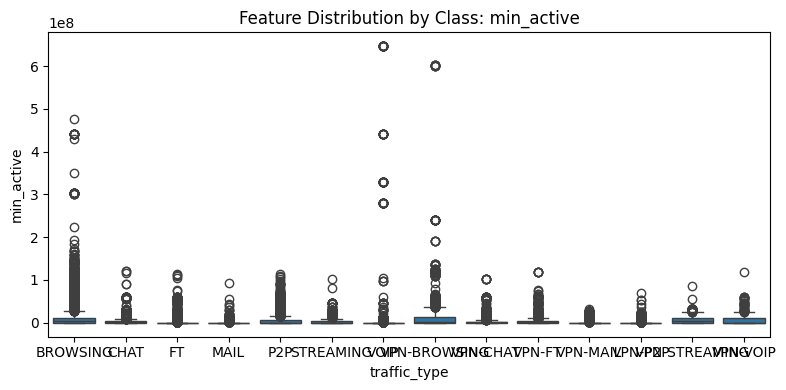

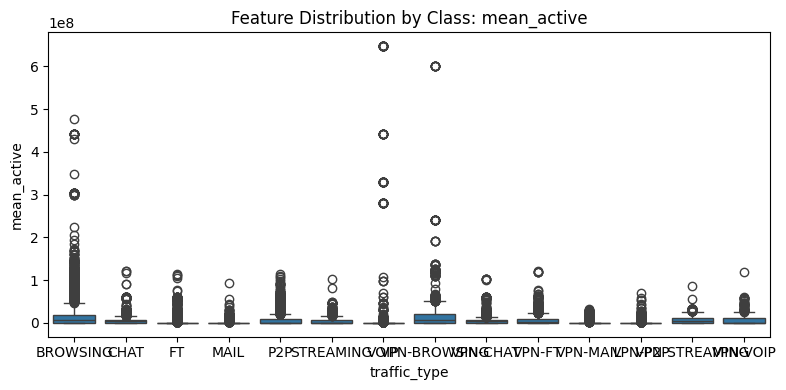

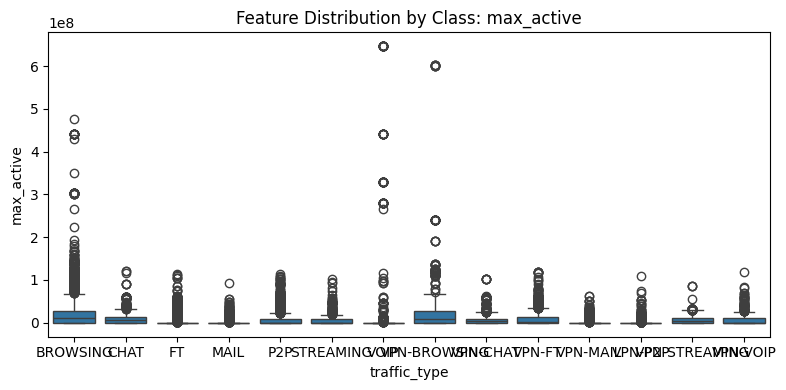

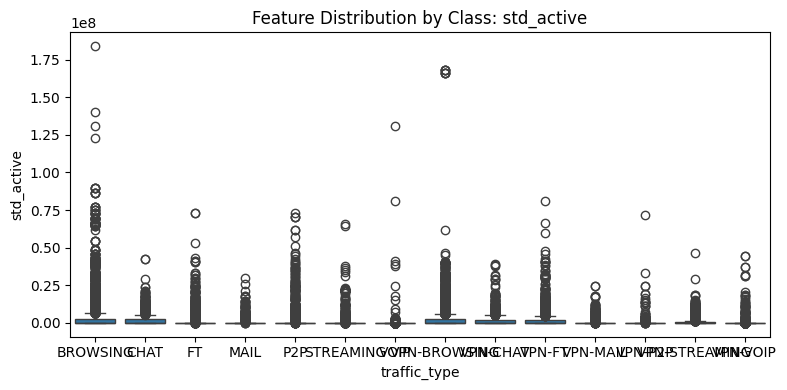

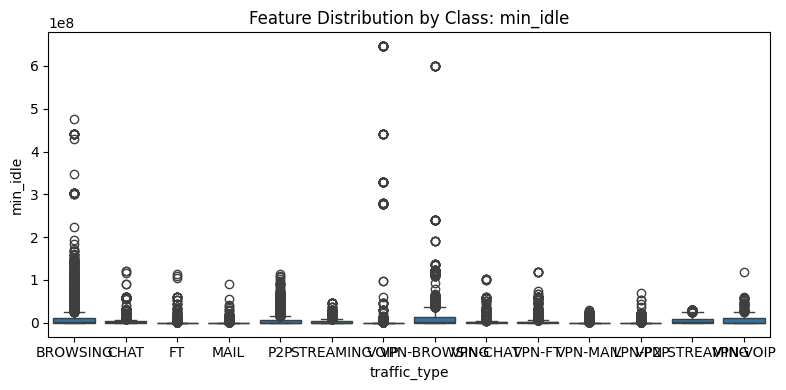

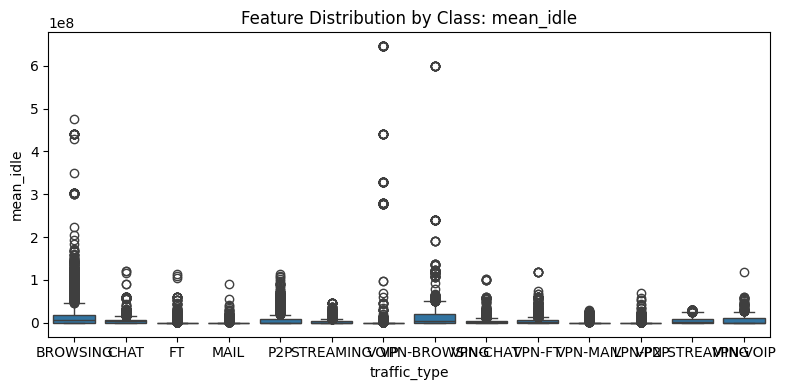

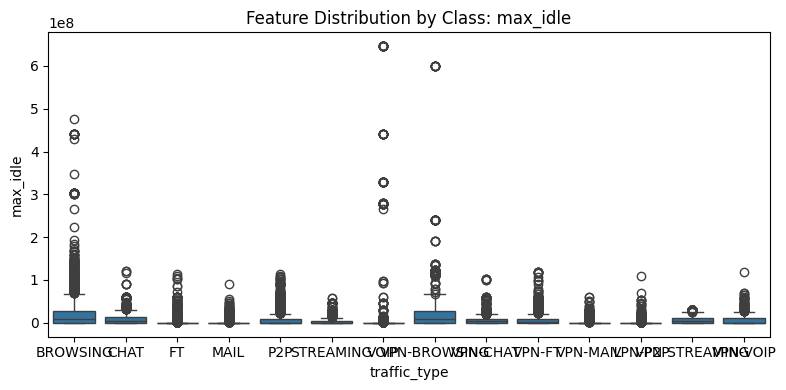

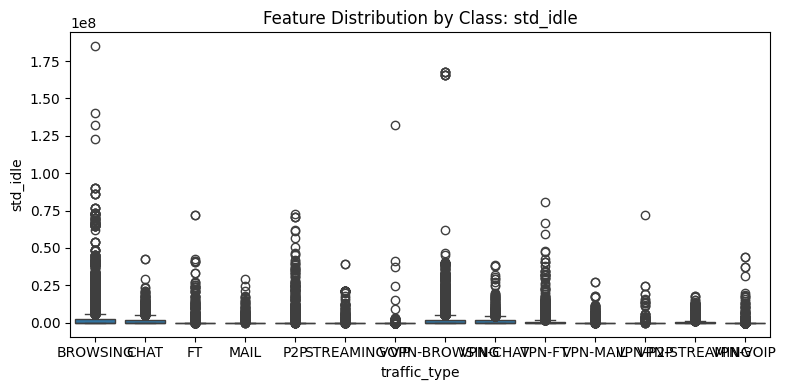

In [6]:
for col in numeric_cols:
    if col != target_column:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=target_column, y=col, data=df)
        plt.title(f"Feature Distribution by Class: {col}")
        plt.tight_layout()
        plt.show()

## 7. Correlation Matrix

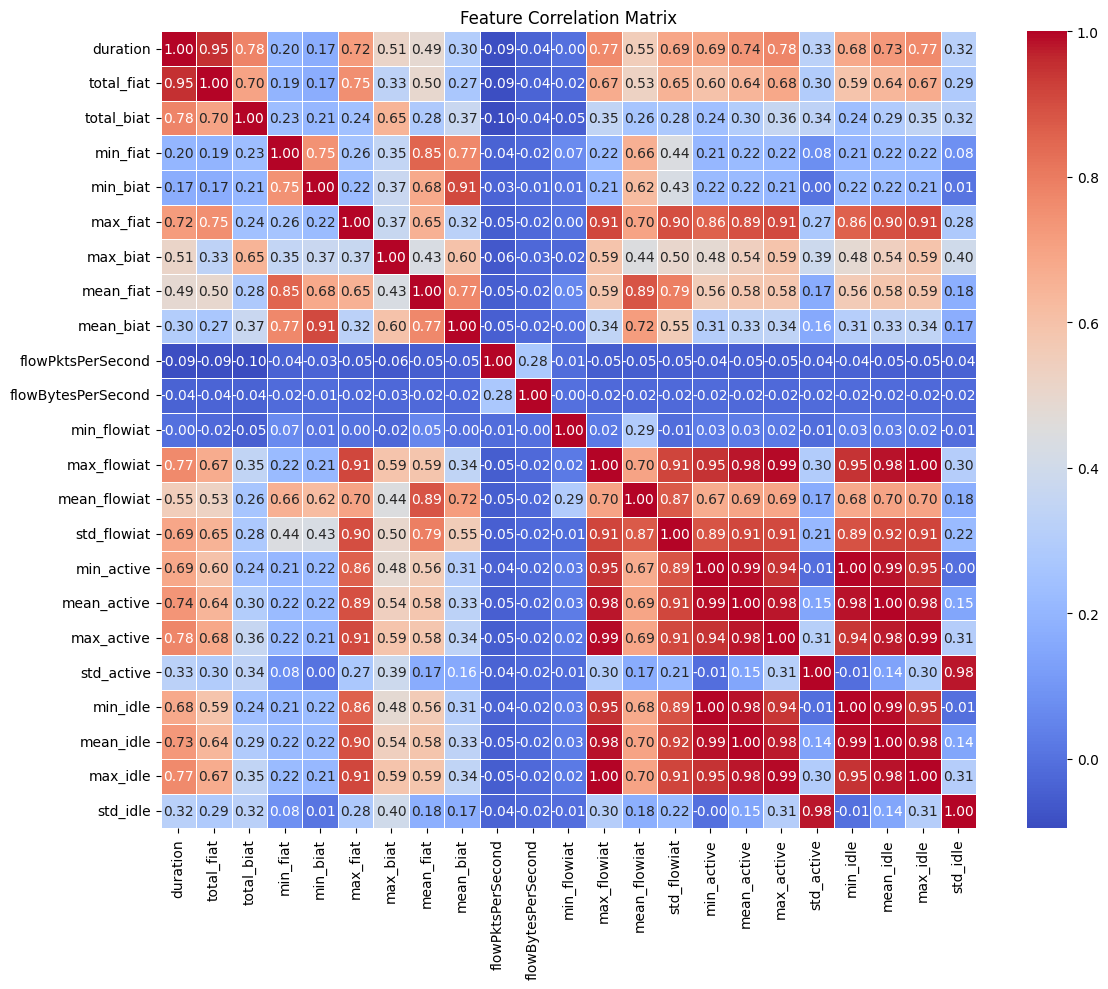

In [7]:
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 8. High-Correlation Feature Detection

In [8]:
threshold = 0.85
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [c for c in upper_tri.columns if any(upper_tri[c].abs() > threshold)]
print(f"Features with correlation above {threshold}:")
print(high_corr_features)

Features with correlation above 0.85:
['total_fiat', 'mean_fiat', 'mean_biat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle']


## 9. Infinity & NaN Removal

In [9]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
nan_count = df.isna().sum().sum()
print(f"Total NaN values after inf conversion: {nan_count}")
df.dropna(inplace=True)
print(f"Rows after NaN removal: {df.shape[0]}")

Total NaN values after inf conversion: 0
Rows after NaN removal: 59706


## 10. Duplicate Removal

In [10]:
rows_before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Rows removed: {rows_before - df.shape[0]}")
print(f"Rows remaining: {df.shape[0]}")

Rows removed: 18719
Rows remaining: 40987


## 11. Negative Value Correction

In [11]:
for col in numeric_cols:
    if (df[col] < 0).any():
        print(f"Warning: negative values found in '{col}'. Clipping to 0.")
        df[col] = np.where(df[col] < 0, 0, df[col])

## 12. Export Cleaned Dataset

In [12]:
OUTPUT_PATH = "../data/processed/cleaned_traffic_data.csv"
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
print(f"Cleaned dataset saved to '{OUTPUT_PATH}'")
print(f"Final shape: {df.shape}")

Cleaned dataset saved to '../data/processed/cleaned_traffic_data.csv'
Final shape: (40987, 24)
